In [1]:
# ============================================================
# CELL 1: Imports, Reproducibility, GPU Setup, File Upload
# Case III: Inverse PINN for Fisher-KPP — BOTH D and r Unknown
# ============================================================

import os
import copy
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---------------------------
# Device configuration (Colab GPU)
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

torch.set_default_dtype(torch.float32)

# ---------------------------
# File upload (Colab widget)
# ---------------------------
from google.colab import files

DATA_FILENAME = "FisherKPP_Inverse_PINN_Dataset.csv"   # Dataset 1: D_true=0.01, r_true=1.0
DATA_PATH = f"/content/{DATA_FILENAME}"

if not os.path.exists(DATA_PATH):
    print(f"Please upload: {DATA_FILENAME}")
    uploaded = files.upload()
    uploaded_name = list(uploaded.keys())[0]
    if uploaded_name != DATA_FILENAME:
        os.rename(uploaded_name, DATA_PATH)
else:
    print(f"Found existing file at {DATA_PATH}")

print("Setup complete.")

Using device: cuda
GPU: Tesla T4
Please upload: FisherKPP_Inverse_PINN_Dataset.csv


Saving FisherKPP_Inverse_PINN_Dataset.csv to FisherKPP_Inverse_PINN_Dataset.csv
Setup complete.


Raw data shape: (321600, 3)
       x    t         u
0  0.000  0.0  0.000000
1  0.005  0.0  0.000005
2  0.010  0.0  0.000006
3  0.015  0.0  0.000008
4  0.020  0.0  0.000010
Detected grid: Nx=201, Nt=1600

Max |FDM IC - Analytical IC| at t=0: 3.727e-06  (should be ~1e-6)
Max |u(0,t)|: 0.000e+00
Max |u(1,t)|: 0.000e+00
Fraction of nonzero u values: 0.9900


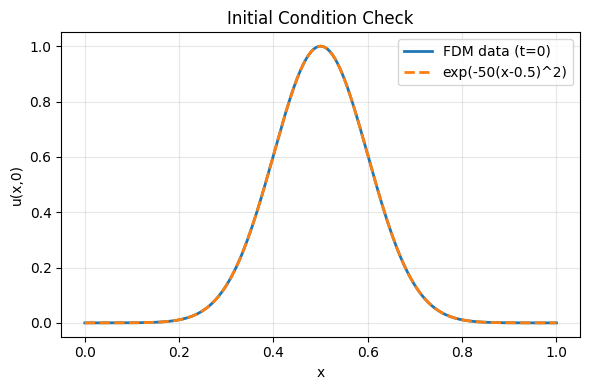

In [3]:
# ============================================================
# CELL 2: Load Dataset, Reshape to Grid, Verify IC/BC
# ============================================================

df = pd.read_csv(DATA_PATH)
print("Raw data shape:", df.shape)
print(df.head())

x_grid = np.sort(df["x"].unique())
t_grid = np.sort(df["t"].unique())
Nx = len(x_grid)
Nt = len(t_grid)
print(f"Detected grid: Nx={Nx}, Nt={Nt}")

df_sorted = df.sort_values(by=["t", "x"]).reset_index(drop=True)
U_grid = df_sorted["u"].values.reshape(Nt, Nx)   # U_grid[j, i] = u(x_i, t_j)

# ---------------------------
# IC verification (corrected Gaussian-only formula, confirmed against FDM data)
# u(x,0) = exp(-50*(x-0.5)^2)
# ---------------------------
u_ic_fdm = U_grid[0, :]
u_ic_analytical = np.exp(-50 * (x_grid - 0.5)**2)
ic_max_diff = np.max(np.abs(u_ic_fdm - u_ic_analytical))
print(f"\nMax |FDM IC - Analytical IC| at t=0: {ic_max_diff:.3e}  (should be ~1e-6)")

# ---------------------------
# BC verification: u(0,t) = 0, u(1,t) = 0
# ---------------------------
print(f"Max |u(0,t)|: {np.max(np.abs(U_grid[:, 0])):.3e}")
print(f"Max |u(1,t)|: {np.max(np.abs(U_grid[:, -1])):.3e}")

nonzero_frac = (df["u"] != 0).mean()
print(f"Fraction of nonzero u values: {nonzero_frac:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(x_grid, u_ic_fdm, label="FDM data (t=0)", lw=2)
plt.plot(x_grid, u_ic_analytical, "--", label="exp(-50(x-0.5)^2)", lw=2)
plt.xlabel("x"); plt.ylabel("u(x,0)")
plt.title("Initial Condition Check")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [4]:
# ============================================================
# CELL 3: Prepare Training Data (data / collocation / IC / BC)
# ============================================================

# ---------------------------
# 1. DATA POINTS
# ---------------------------
N_data = 10000
data_sample = df.sample(n=N_data, random_state=42).reset_index(drop=True)

X_data = data_sample[["x", "t"]].values
U_data = data_sample[["u"]].values

X_train, X_val, U_train, U_val = train_test_split(
    X_data, U_data, test_size=0.20, random_state=42
)

x_train_t = torch.tensor(X_train[:, 0:1], dtype=torch.float32, device=device)
t_train_t = torch.tensor(X_train[:, 1:2], dtype=torch.float32, device=device)
u_train_t = torch.tensor(U_train, dtype=torch.float32, device=device)

x_val_t = torch.tensor(X_val[:, 0:1], dtype=torch.float32, device=device)
t_val_t = torch.tensor(X_val[:, 1:2], dtype=torch.float32, device=device)
u_val_t = torch.tensor(U_val, dtype=torch.float32, device=device)

print(f"Training data points:   {x_train_t.shape[0]}")
print(f"Validation data points: {x_val_t.shape[0]}")

# ---------------------------
# 2. COLLOCATION POINTS
# ---------------------------
N_f = 10000
np.random.seed(42)
x_f = np.random.uniform(0, 1, (N_f, 1))
t_f = np.random.uniform(1e-4, 1, (N_f, 1))

x_f_t = torch.tensor(x_f, dtype=torch.float32, device=device, requires_grad=True)
t_f_t = torch.tensor(t_f, dtype=torch.float32, device=device, requires_grad=True)

print(f"Collocation points: {x_f_t.shape[0]}")

# ---------------------------
# 3. INITIAL CONDITION POINTS
# ---------------------------
N_ic = 200
x_ic = np.linspace(0, 1, N_ic).reshape(-1, 1)
t_ic = np.zeros_like(x_ic)
u_ic_target = np.exp(-50 * (x_ic - 0.5)**2)

x_ic_t = torch.tensor(x_ic, dtype=torch.float32, device=device)
t_ic_t = torch.tensor(t_ic, dtype=torch.float32, device=device)
u_ic_target_t = torch.tensor(u_ic_target, dtype=torch.float32, device=device)

print(f"IC points: {x_ic_t.shape[0]}")

# ---------------------------
# 4. BOUNDARY CONDITION POINTS
# ---------------------------
N_bc = 200
np.random.seed(42)
t_bc = np.random.uniform(0, 1, (N_bc, 1))

x_left_t = torch.tensor(np.zeros_like(t_bc), dtype=torch.float32, device=device)
x_right_t = torch.tensor(np.ones_like(t_bc), dtype=torch.float32, device=device)
t_bc_t = torch.tensor(t_bc, dtype=torch.float32, device=device)
u_bc_target_t = torch.zeros((N_bc, 1), dtype=torch.float32, device=device)

print(f"BC points: {N_bc} (left) + {N_bc} (right)")
print("\nAll training tensors prepared on device:", device)

Training data points:   8000
Validation data points: 2000
Collocation points: 10000
IC points: 200
BC points: 200 (left) + 200 (right)

All training tensors prepared on device: cuda


In [5]:
# ============================================================
# CELL 4: PINN Architecture — Both D and r Unknown
# ============================================================

class PINN_DR(nn.Module):
    """
    Inverse PINN for Fisher-KPP with BOTH D and r unknown.
    u_t = D*u_xx + r*u*(1-u)
    D = exp(logD), r = exp(logr)  -- both guaranteed positive.
    """
    def __init__(self, layers=[2, 50, 50, 50, 50, 50, 50, 50, 1],
                 logD_init=-4.0, logr_init=0.0):
        super(PINN_DR, self).__init__()

        self.linears = nn.ModuleList(
            [nn.Linear(layers[i], layers[i+1]) for i in range(len(layers) - 1)]
        )
        self.activation = nn.Tanh()

        for layer in self.linears:
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)

        # Two unknown physical parameters, both log-parameterized
        self.logD = nn.Parameter(torch.tensor([logD_init], dtype=torch.float32))
        self.logr = nn.Parameter(torch.tensor([logr_init], dtype=torch.float32))

    @property
    def D(self):
        return torch.exp(self.logD)

    @property
    def r(self):
        return torch.exp(self.logr)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        out = inp
        for i, layer in enumerate(self.linears):
            out = layer(out)
            if i < len(self.linears) - 1:
                out = self.activation(out)
        return out


model = PINN_DR(layers=[2, 50, 50, 50, 50, 50, 50, 50, 1],
                logD_init=-4.0, logr_init=0.0).to(device)

print(model)
print(f"\nInitial D = {model.D.item():.6f}  (true D = 0.01)")
print(f"Initial r = {model.r.item():.6f}  (true r = 1.0)")
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters())}")

PINN_DR(
  (linears): ModuleList(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1-6): 6 x Linear(in_features=50, out_features=50, bias=True)
    (7): Linear(in_features=50, out_features=1, bias=True)
  )
  (activation): Tanh()
)

Initial D = 0.018316  (true D = 0.01)
Initial r = 1.000000  (true r = 1.0)
Total trainable parameters: 15503


In [6]:
# ============================================================
# CELL 5: Derivative Computation and PDE Residual (Joint D, r)
# ============================================================

def compute_derivatives(model, x, t):
    u = model(x, t)

    u_t = torch.autograd.grad(
        u, t, grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]

    u_x = torch.autograd.grad(
        u, x, grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x, x, grad_outputs=torch.ones_like(u_x),
        create_graph=True, retain_graph=True
    )[0]

    return u, u_t, u_x, u_xx


def pde_residual(model, x, t):
    """
    Fisher-KPP residual with BOTH D and r unknown (pulled from model).
    f = u_t - D*u_xx - r*u*(1-u)
    """
    u, u_t, u_x, u_xx = compute_derivatives(model, x, t)
    D = model.D
    r = model.r
    f = u_t - D * u_xx - r * u * (1 - u)
    return f


print("Derivative and joint D/r PDE residual functions defined.")

test_f = pde_residual(model, x_f_t[:5], t_f_t[:5])
print("Sample PDE residual shape:", test_f.shape)
print("Sample PDE residual values:", test_f.detach().cpu().numpy().flatten())

Derivative and joint D/r PDE residual functions defined.
Sample PDE residual shape: torch.Size([5, 1])
Sample PDE residual values: [0.10714086 0.3239332  0.22572842 0.23035435 0.02483653]


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


In [7]:
# ============================================================
# CELL 6: Loss Functions
# ============================================================

mse = nn.MSELoss()

def loss_data(model, x, t, u_true):
    u_pred = model(x, t)
    return mse(u_pred, u_true)

def loss_pde(model, x_f, t_f):
    f = pde_residual(model, x_f, t_f)
    return mse(f, torch.zeros_like(f))

def loss_ic(model, x_ic, t_ic, u_ic_target):
    u_pred = model(x_ic, t_ic)
    return mse(u_pred, u_ic_target)

def loss_bc(model, x_left, x_right, t_bc, u_bc_target):
    u_left_pred = model(x_left, t_bc)
    u_right_pred = model(x_right, t_bc)
    return mse(u_left_pred, u_bc_target) + mse(u_right_pred, u_bc_target)


def total_loss(model, x_data, t_data, u_data,
               x_f, t_f,
               x_ic, t_ic, u_ic_target,
               x_left, x_right, t_bc, u_bc_target,
               w_data=100.0, w_pde=1.0, w_ic=10.0, w_bc=10.0):
    L_data = loss_data(model, x_data, t_data, u_data)
    L_pde  = loss_pde(model, x_f, t_f)
    L_ic   = loss_ic(model, x_ic, t_ic, u_ic_target)
    L_bc   = loss_bc(model, x_left, x_right, t_bc, u_bc_target)

    L_total = w_data * L_data + w_pde * L_pde + w_ic * L_ic + w_bc * L_bc
    return L_total, L_data, L_pde, L_ic, L_bc


print("Loss functions defined.")

Loss functions defined.


In [8]:
# ============================================================
# CELL 7: Optimizer — Three Parameter Groups
# ============================================================

network_params = []
for layer in model.linears:
    network_params += list(layer.parameters())

optimizer = torch.optim.Adam([
    {"params": network_params, "lr": 1e-3},
    {"params": [model.logr], "lr": 5e-4},
    {"params": [model.logD], "lr": 2.5e-4}   # slower: more cautious updates for D
])

print("Optimizer parameter groups (Case III: Joint D/r recovery):")
for i, g in enumerate(optimizer.param_groups):
    n_params = sum(p.numel() for p in g["params"])
    print(f"  Group {i}: lr={g['lr']}, num_params={n_params}")

Optimizer parameter groups (Case III: Joint D/r recovery):
  Group 0: lr=0.001, num_params=15501
  Group 1: lr=0.0005, num_params=1
  Group 2: lr=0.00025, num_params=1


In [9]:
# ============================================================
# CELL 8: Training Loop — Joint D/r Recovery (Case III)
# ============================================================

EPOCHS = 12000
PATIENCE = 2000
MIN_DELTA = 1e-8
D_true = 0.01
r_true = 1.0

history = {
    "train_total": [], "train_data": [], "train_pde": [], "train_ic": [], "train_bc": [],
    "val_total": [],
    "D": [], "r": [],
    "D_error_pct": [], "r_error_pct": []
}

best_val_loss = float("inf")
best_epoch = -1
best_model_state = None
patience_counter = 0

start_time = time.time()

for epoch in range(EPOCHS):
    # TRAINING STEP
    model.train()
    optimizer.zero_grad()

    L_total, L_data, L_pde, L_ic, L_bc = total_loss(
        model,
        x_train_t, t_train_t, u_train_t,
        x_f_t, t_f_t,
        x_ic_t, t_ic_t, u_ic_target_t,
        x_left_t, x_right_t, t_bc_t, u_bc_target_t
    )
    L_total.backward()
    optimizer.step()

    # VALIDATION STEP (full weighted loss)
    model.eval()
    Lv_total, Lv_data, Lv_pde, Lv_ic, Lv_bc = total_loss(
        model,
        x_val_t, t_val_t, u_val_t,
        x_f_t, t_f_t,
        x_ic_t, t_ic_t, u_ic_target_t,
        x_left_t, x_right_t, t_bc_t, u_bc_target_t
    )

    # Logging
    D_current = model.D.item()
    r_current = model.r.item()
    D_err_pct = abs(D_current - D_true) / D_true * 100.0
    r_err_pct = abs(r_current - r_true) / r_true * 100.0

    history["train_total"].append(L_total.item())
    history["train_data"].append(L_data.item())
    history["train_pde"].append(L_pde.item())
    history["train_ic"].append(L_ic.item())
    history["train_bc"].append(L_bc.item())
    history["val_total"].append(Lv_total.item())
    history["D"].append(D_current)
    history["r"].append(r_current)
    history["D_error_pct"].append(D_err_pct)
    history["r_error_pct"].append(r_err_pct)

    # Early stopping
    current_val = Lv_total.item()
    if current_val < best_val_loss - MIN_DELTA:
        best_val_loss = current_val
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 500 == 0 or epoch == 0:
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1:5d}/{EPOCHS} | "
              f"Train: {L_total.item():.4e} | Val: {current_val:.4e} | "
              f"D={D_current:.6f} (err {D_err_pct:.3f}%) | "
              f"r={r_current:.6f} (err {r_err_pct:.3f}%) | "
              f"Patience {patience_counter}/{PATIENCE} | {elapsed:.1f}s")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}. "
              f"Best epoch: {best_epoch+1} with val loss {best_val_loss:.6e}")
        break

total_time = time.time() - start_time
print(f"\nTraining finished in {total_time:.1f}s ({epoch+1} epochs run)")

# Restore best validation model
model.load_state_dict(best_model_state)
model.eval()

D_final = model.D.item()
r_final = model.r.item()
print(f"\nBest model restored from epoch {best_epoch+1}")
print(f"Recovered D = {D_final:.6f}  (true D = {D_true}) -> error {abs(D_final-D_true)/D_true*100:.4f}%")
print(f"Recovered r = {r_final:.6f}  (true r = {r_true}) -> error {abs(r_final-r_true)/r_true*100:.4f}%")

Epoch     1/12000 | Train: 3.7706e+01 | Val: 1.6081e+01 | D=0.018320 (err 83.202%) | r=0.999500 (err 0.050%) | Patience 0/2000 | 0.6s
Epoch   500/12000 | Train: 2.4436e-02 | Val: 2.4443e-02 | D=0.016402 (err 64.019%) | r=0.994191 (err 0.581%) | Patience 0/2000 | 14.5s
Epoch  1000/12000 | Train: 1.4218e-02 | Val: 1.3666e-02 | D=0.015115 (err 51.154%) | r=1.078599 (err 7.860%) | Patience 7/2000 | 27.9s
Epoch  1500/12000 | Train: 6.7625e-03 | Val: 6.7453e-03 | D=0.014075 (err 40.754%) | r=1.077003 (err 7.700%) | Patience 4/2000 | 41.2s
Epoch  2000/12000 | Train: 3.9376e-03 | Val: 3.9286e-03 | D=0.013208 (err 32.076%) | r=1.059501 (err 5.950%) | Patience 0/2000 | 54.0s
Epoch  2500/12000 | Train: 2.6174e-03 | Val: 2.5102e-03 | D=0.012477 (err 24.769%) | r=1.044973 (err 4.497%) | Patience 4/2000 | 67.0s
Epoch  3000/12000 | Train: 1.7200e-03 | Val: 1.7901e-03 | D=0.011855 (err 18.552%) | r=1.032939 (err 3.294%) | Patience 7/2000 | 79.8s
Epoch  3500/12000 | Train: 8.1240e-02 | Val: 7.7128e-02 

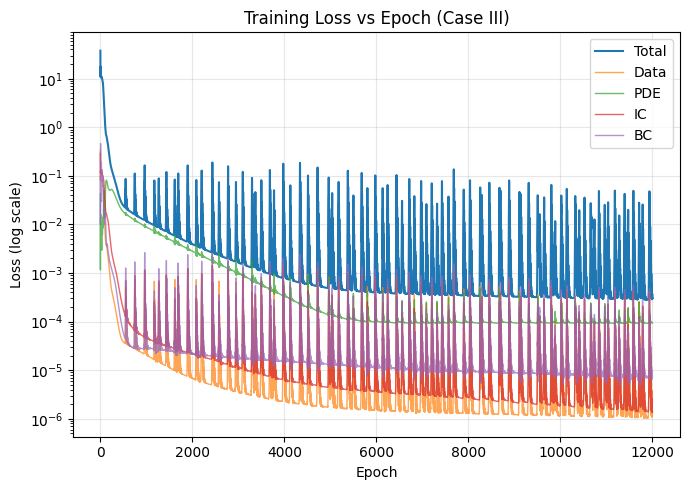

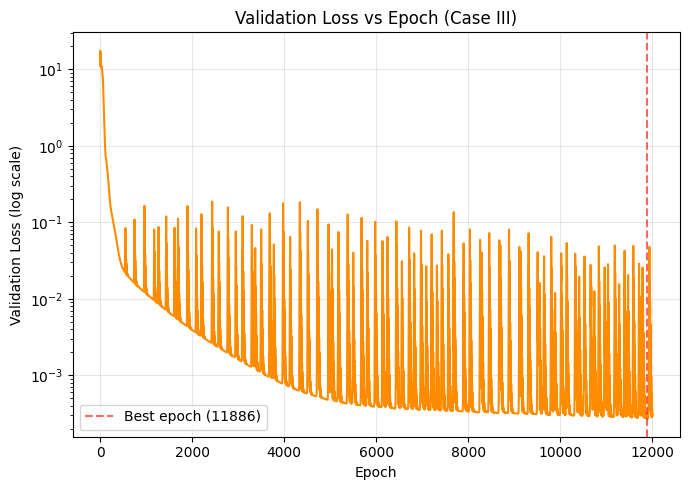

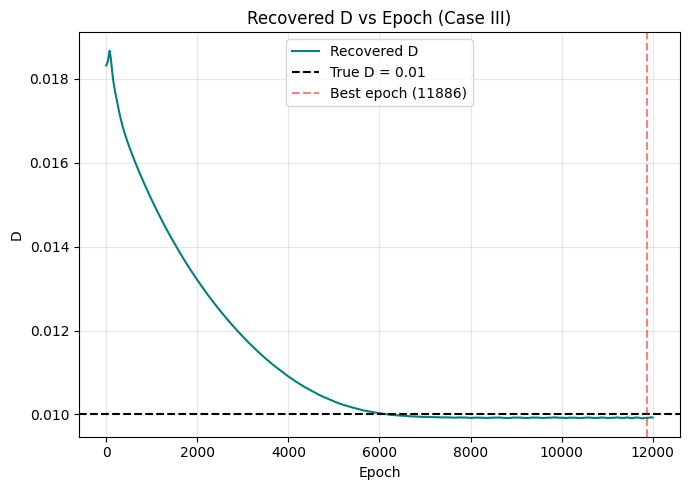

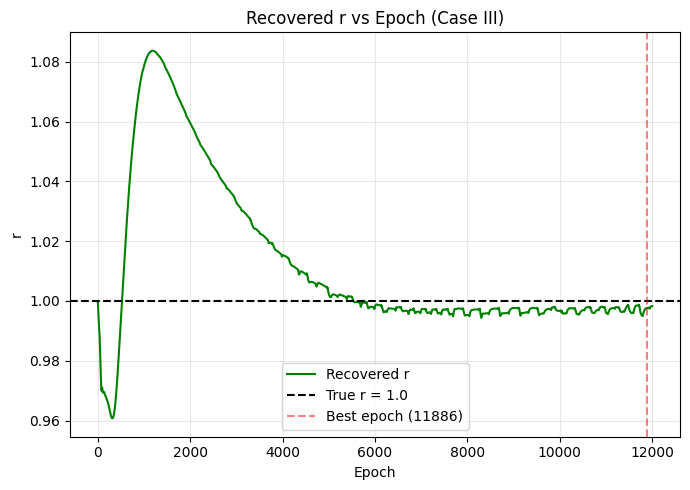

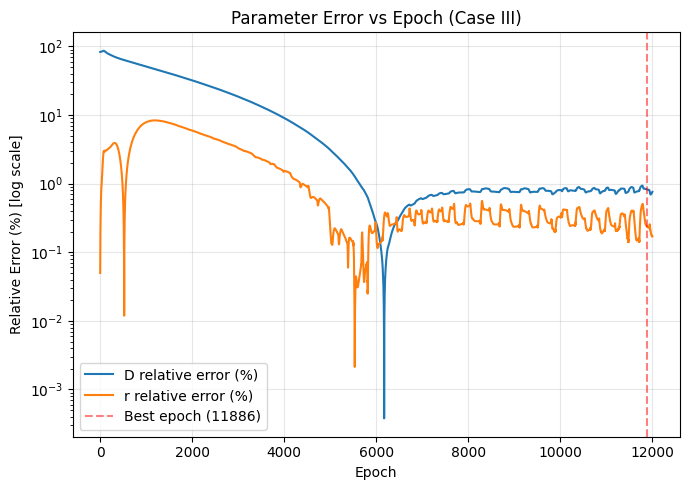

Plots 1-5 saved.


In [10]:
# ============================================================
# CELL 9: Plots — Loss Curves, D/r Convergence, Parameter Error
# ============================================================

epochs_range = np.arange(1, len(history["train_total"]) + 1)

# Plot 1: Training Loss
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["train_total"], label="Total", lw=1.5)
plt.plot(epochs_range, history["train_data"], label="Data", lw=1, alpha=0.7)
plt.plot(epochs_range, history["train_pde"], label="PDE", lw=1, alpha=0.7)
plt.plot(epochs_range, history["train_ic"], label="IC", lw=1, alpha=0.7)
plt.plot(epochs_range, history["train_bc"], label="BC", lw=1, alpha=0.7)
plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("Loss (log scale)")
plt.title("Training Loss vs Epoch (Case III)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/case3_plot1_training_loss.png", dpi=150)
plt.show()

# Plot 2: Validation Loss
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["val_total"], color="darkorange", lw=1.5)
plt.axvline(best_epoch + 1, color="red", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch+1})")
plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("Validation Loss (log scale)")
plt.title("Validation Loss vs Epoch (Case III)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/case3_plot2_validation_loss.png", dpi=150)
plt.show()

# Plot 3: D vs Epoch
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["D"], color="teal", lw=1.5, label="Recovered D")
plt.axhline(D_true, color="black", linestyle="--", label=f"True D = {D_true}")
plt.axvline(best_epoch + 1, color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({best_epoch+1})")
plt.xlabel("Epoch"); plt.ylabel("D")
plt.title("Recovered D vs Epoch (Case III)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/case3_plot3_D_convergence.png", dpi=150)
plt.show()

# Plot 4: r vs Epoch
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["r"], color="green", lw=1.5, label="Recovered r")
plt.axhline(r_true, color="black", linestyle="--", label=f"True r = {r_true}")
plt.axvline(best_epoch + 1, color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({best_epoch+1})")
plt.xlabel("Epoch"); plt.ylabel("r")
plt.title("Recovered r vs Epoch (Case III)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/case3_plot4_r_convergence.png", dpi=150)
plt.show()

# Plot 5: Parameter Error (%) vs Epoch -- both D and r
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["D_error_pct"], label="D relative error (%)", lw=1.5)
plt.plot(epochs_range, history["r_error_pct"], label="r relative error (%)", lw=1.5)
plt.axvline(best_epoch + 1, color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({best_epoch+1})")
plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("Relative Error (%) [log scale]")
plt.title("Parameter Error vs Epoch (Case III)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/case3_plot5_param_error.png", dpi=150)
plt.show()

print("Plots 1-5 saved.")

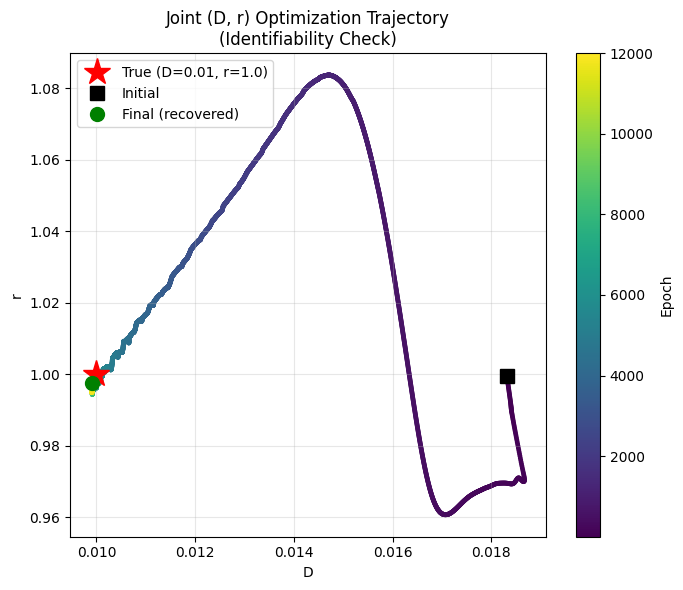

Joint trajectory plot saved.


In [11]:
# ============================================================
# CELL 10: Joint (D, r) Trajectory Plot — Identifiability Check
# ============================================================

plt.figure(figsize=(7, 6))
sc = plt.scatter(history["D"], history["r"], c=epochs_range, cmap="viridis", s=6)
plt.plot(D_true, r_true, "r*", markersize=20, label=f"True (D={D_true}, r={r_true})")
plt.plot(history["D"][0], history["r"][0], "ks", markersize=10, label="Initial")
plt.plot(D_final, r_final, "go", markersize=10, label="Final (recovered)")
plt.colorbar(sc, label="Epoch")
plt.xlabel("D"); plt.ylabel("r")
plt.title("Joint (D, r) Optimization Trajectory\n(Identifiability Check)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/case3_plot6_joint_trajectory.png", dpi=150)
plt.show()

print("Joint trajectory plot saved.")

In [12]:
# ============================================================
# CELL 11: Full-Field PINN Inference
# ============================================================

model.eval()

X_full, T_full = np.meshgrid(x_grid, t_grid)
x_full_flat = X_full.reshape(-1, 1)
t_full_flat = T_full.reshape(-1, 1)

x_full_t = torch.tensor(x_full_flat, dtype=torch.float32, device=device)
t_full_t = torch.tensor(t_full_flat, dtype=torch.float32, device=device)

batch_size = 20000
preds = []
with torch.no_grad():
    for i in range(0, x_full_t.shape[0], batch_size):
        u_pred_batch = model(x_full_t[i:i+batch_size], t_full_t[i:i+batch_size])
        preds.append(u_pred_batch.cpu().numpy())

U_pred_grid = np.concatenate(preds, axis=0).reshape(Nt, Nx)
Abs_Error_grid = np.abs(U_pred_grid - U_grid)

print("PINN full-field prediction computed.")
print(f"Max absolute error: {Abs_Error_grid.max():.6e}")
print(f"Mean absolute error: {Abs_Error_grid.mean():.6e}")

PINN full-field prediction computed.
Max absolute error: 8.347463e-03
Mean absolute error: 6.978372e-04


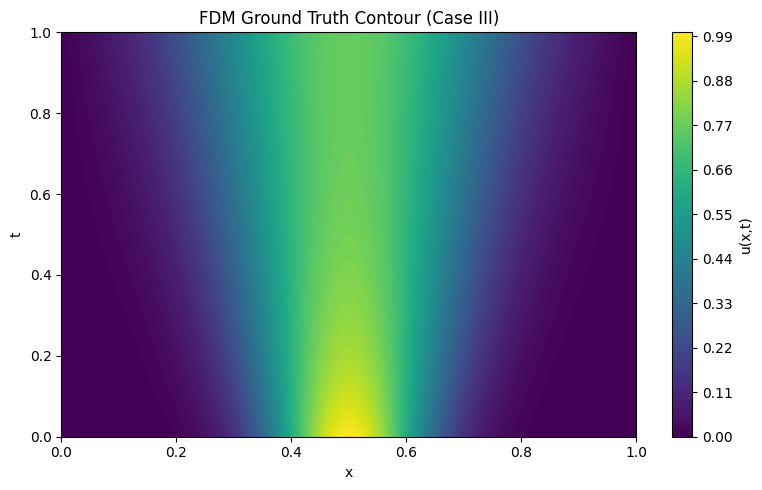

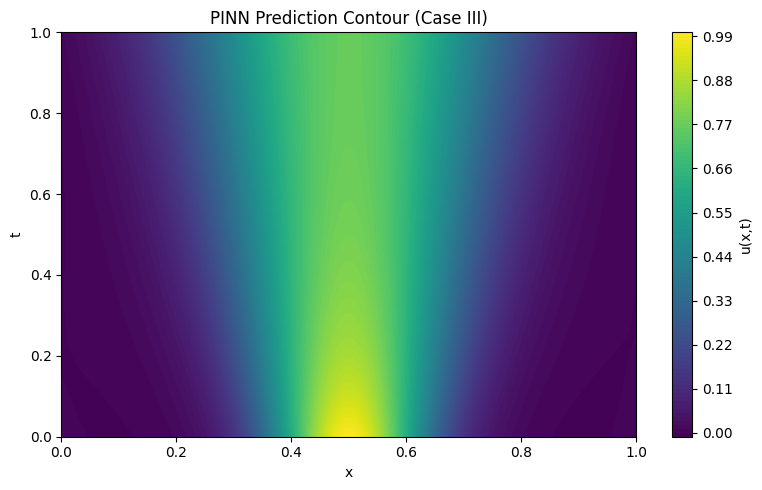

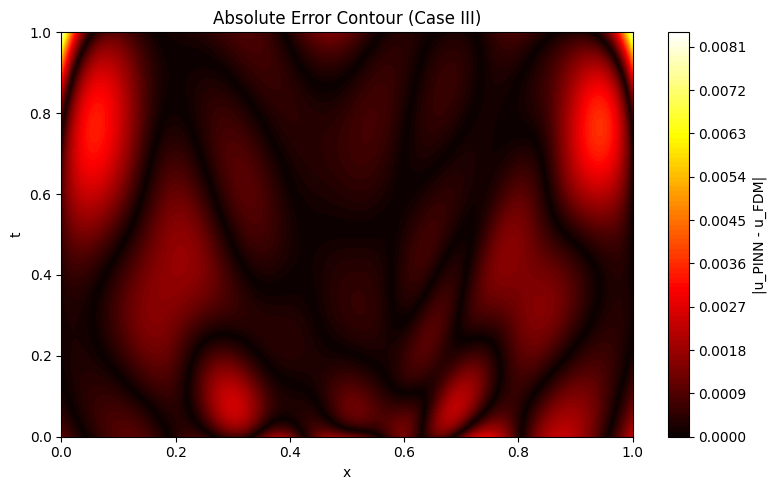

Contour plots saved.


In [13]:
# ============================================================
# CELL 12: Contour Plots — FDM, PINN, Absolute Error
# ============================================================

plt.figure(figsize=(8, 5))
cp1 = plt.contourf(X_full, T_full, U_grid, levels=100, cmap="viridis")
plt.colorbar(cp1, label="u(x,t)")
plt.xlabel("x"); plt.ylabel("t")
plt.title("FDM Ground Truth Contour (Case III)")
plt.tight_layout()
plt.savefig("/content/case3_plot7_fdm_contour.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
cp2 = plt.contourf(X_full, T_full, U_pred_grid, levels=100, cmap="viridis")
plt.colorbar(cp2, label="u(x,t)")
plt.xlabel("x"); plt.ylabel("t")
plt.title("PINN Prediction Contour (Case III)")
plt.tight_layout()
plt.savefig("/content/case3_plot8_pinn_contour.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
cp3 = plt.contourf(X_full, T_full, Abs_Error_grid, levels=100, cmap="hot")
plt.colorbar(cp3, label="|u_PINN - u_FDM|")
plt.xlabel("x"); plt.ylabel("t")
plt.title("Absolute Error Contour (Case III)")
plt.tight_layout()
plt.savefig("/content/case3_plot9_abs_error_contour.png", dpi=150)
plt.show()

print("Contour plots saved.")

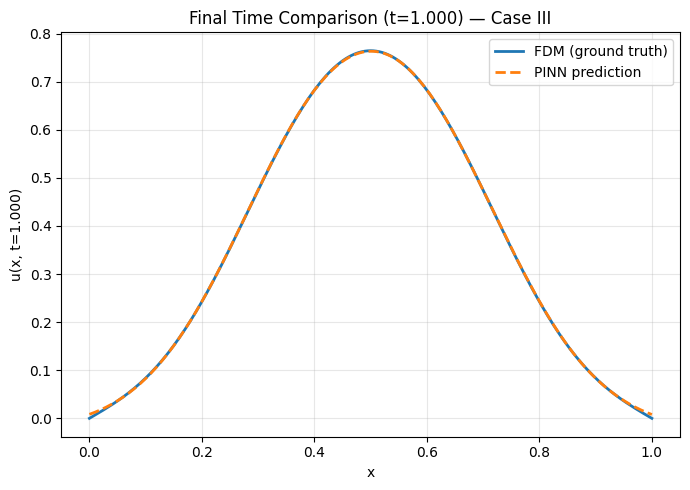

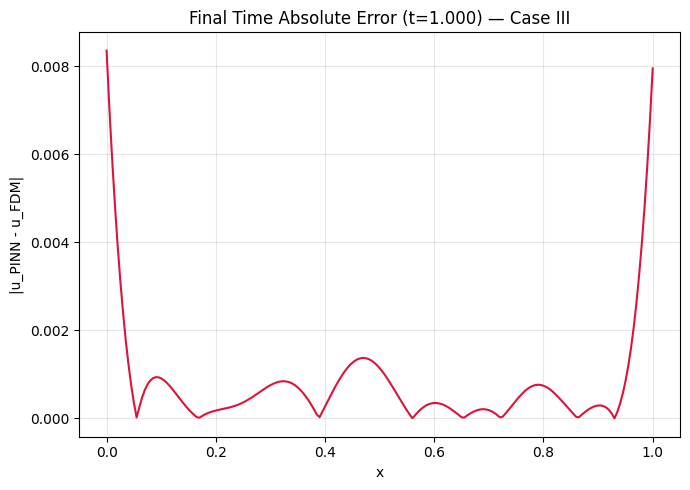

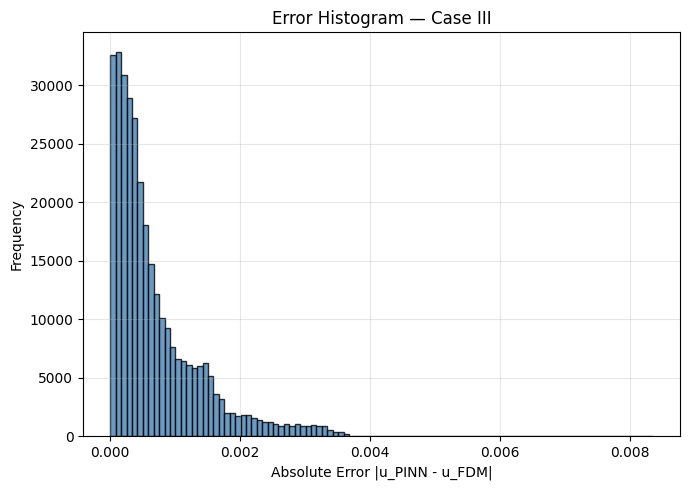

Final-time and histogram plots saved.


In [14]:
# ============================================================
# CELL 13: Final Time Comparison, Error, and Histogram
# ============================================================

final_t_idx = -1
final_t_value = t_grid[final_t_idx]

u_fdm_final = U_grid[final_t_idx, :]
u_pinn_final = U_pred_grid[final_t_idx, :]
error_final = np.abs(u_pinn_final - u_fdm_final)

plt.figure(figsize=(7, 5))
plt.plot(x_grid, u_fdm_final, label="FDM (ground truth)", lw=2)
plt.plot(x_grid, u_pinn_final, "--", label="PINN prediction", lw=2)
plt.xlabel("x"); plt.ylabel(f"u(x, t={final_t_value:.3f})")
plt.title(f"Final Time Comparison (t={final_t_value:.3f}) — Case III")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/case3_plot10_final_time_comparison.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(x_grid, error_final, color="crimson", lw=1.5)
plt.xlabel("x"); plt.ylabel("|u_PINN - u_FDM|")
plt.title(f"Final Time Absolute Error (t={final_t_value:.3f}) — Case III")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/case3_plot11_final_time_error.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(Abs_Error_grid.flatten(), bins=100, color="steelblue", edgecolor="black", alpha=0.8)
plt.xlabel("Absolute Error |u_PINN - u_FDM|")
plt.ylabel("Frequency")
plt.title("Error Histogram — Case III")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("/content/case3_plot12_error_histogram.png", dpi=150)
plt.show()

print("Final-time and histogram plots saved.")

In [15]:
# ============================================================
# CELL 14: Final Metrics Report — Case III
# ============================================================

error_field = U_pred_grid - U_grid
RMSE = np.sqrt(np.mean(error_field**2))
MAE = np.mean(np.abs(error_field))
Relative_L2 = np.linalg.norm(error_field) / np.linalg.norm(U_grid)
Max_Abs_Error = np.max(np.abs(error_field))
Mean_Error = np.mean(error_field)
Std_Error = np.std(error_field)

D_rel_error_pct = abs(D_final - D_true) / D_true * 100.0
r_rel_error_pct = abs(r_final - r_true) / r_true * 100.0

print("=" * 65)
print("FINAL METRICS REPORT — Inverse PINN (Fisher-KPP, Case III)")
print("Both D and r Unknown")
print("=" * 65)
print(f"{'True D':<30}: {D_true}")
print(f"{'Recovered D':<30}: {D_final:.6f}")
print(f"{'Relative Error in D (%)':<30}: {D_rel_error_pct:.6f}")
print("-" * 65)
print(f"{'True r':<30}: {r_true}")
print(f"{'Recovered r':<30}: {r_final:.6f}")
print(f"{'Relative Error in r (%)':<30}: {r_rel_error_pct:.6f}")
print("-" * 65)
print(f"{'RMSE':<30}: {RMSE:.6e}")
print(f"{'MAE':<30}: {MAE:.6e}")
print(f"{'Relative L2 Error':<30}: {Relative_L2:.6e}")
print(f"{'Maximum Absolute Error':<30}: {Max_Abs_Error:.6e}")
print(f"{'Mean Error':<30}: {Mean_Error:.6e}")
print(f"{'Standard Deviation of Error':<30}: {Std_Error:.6e}")
print("=" * 65)
print(f"Best epoch (restored model): {best_epoch + 1}")
print(f"Total epochs run: {epoch + 1}")
print("=" * 65)

metrics_dict = {
    "true_D": [D_true], "recovered_D": [D_final], "D_rel_error_pct": [D_rel_error_pct],
    "true_r": [r_true], "recovered_r": [r_final], "r_rel_error_pct": [r_rel_error_pct],
    "RMSE": [RMSE], "MAE": [MAE], "Relative_L2_Error": [Relative_L2],
    "Max_Abs_Error": [Max_Abs_Error], "Mean_Error": [Mean_Error], "Std_Error": [Std_Error],
    "best_epoch": [best_epoch + 1], "total_epochs_run": [epoch + 1]
}
metrics_df = pd.DataFrame(metrics_dict)
metrics_df.to_csv("/content/case3_final_metrics_report.csv", index=False)
print("\nMetrics saved to /content/case3_final_metrics_report.csv")

FINAL METRICS REPORT — Inverse PINN (Fisher-KPP, Case III)
Both D and r Unknown
True D                        : 0.01
Recovered D                   : 0.009918
Relative Error in D (%)       : 0.821736
-----------------------------------------------------------------
True r                        : 1.0
Recovered r                   : 0.997640
Relative Error in r (%)       : 0.235981
-----------------------------------------------------------------
RMSE                          : 1.005632e-03
MAE                           : 6.978372e-04
Relative L2 Error             : 2.383812e-03
Maximum Absolute Error        : 8.347463e-03
Mean Error                    : -1.295601e-04
Standard Deviation of Error   : 9.972509e-04
Best epoch (restored model): 11886
Total epochs run: 12000

Metrics saved to /content/case3_final_metrics_report.csv
